>[Imports](#scrollTo=iiZe8A1OANkW)

>[Loading dependent files](#scrollTo=oqFtNX7aAPtM)

>[Task 1 - Linear Regression](#scrollTo=jIQ9rJ-lAINY)

>[Task 2 - PCA](#scrollTo=IUq3MWGkklhQ)

>[Task 3 - LDA](#scrollTo=ntmAN-5a4Dp_)

>[Task 4 - PCA by hand](#scrollTo=ztY1U2lHNmEn)

>>[Find no of features for 95% variance](#scrollTo=0VP7m68dbLo1)

>>[Rough work](#scrollTo=x1SWXI9CfH_1)

>[Task 5 - Apply your skill](#scrollTo=3by5dQ9h-6Po)

>>[PCA](#scrollTo=E8wE94VlImjS)

>>[LDA](#scrollTo=IdWYYPJJItLa)



#Imports

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

#Loading dependent files

In [10]:
dataset_X_Train = np.load("/content/x_values-1.npy")
dataset_Y_Train = np.load("/content/y_values-1.npy")
dataset_X_Test = np.load("/content/test_x_values-1.npy")
wine_data = np.load("/content/wineData-1.npy")
wine_labels = np.load("/content/wineLabels-1.npy")
task5_data = np.load("/content/task3_5_data.npy")
task5_labels = np.load("/content/task3_5_labels.npy")

#Task 1 - Linear Regression

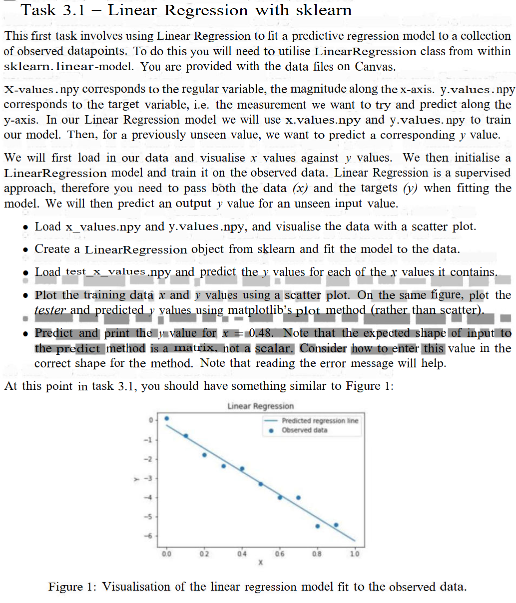

Coefficients: 
 [[-6.0148689]]


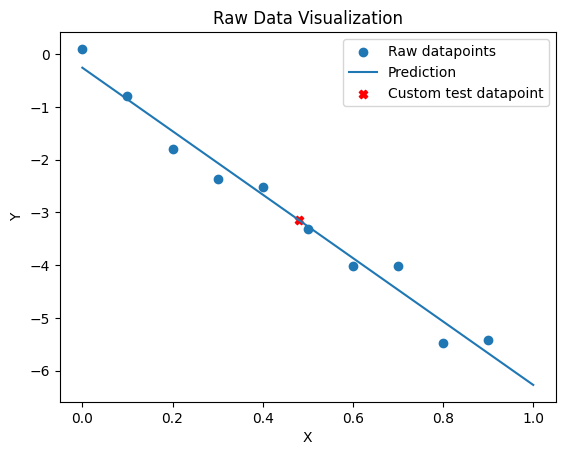

In [4]:
plt.ion()
figure = plt.subplot()

#Visualize original data points
figure.scatter(dataset_X_Train, dataset_Y_Train, label="Raw datapoints")
figure.set_xlabel("X")
figure.set_ylabel("Y")
figure.set_title("Raw Data Visualization")
figure.legend()


#Linear regresssion for test data provided
regr = linear_model.LinearRegression()

# Train the model using the training sets
regr.fit(dataset_X_Train, dataset_Y_Train)

# Make predictions using the testing set
dataset_Y_pred = regr.predict(dataset_X_Test)

# The coefficients
print("Coefficients: \n", regr.coef_)

figure.plot(dataset_X_Test, dataset_Y_pred, label="Prediction")
figure.legend()


#Predict y value for the custom point provided
test_point_prediction = regr.predict([[0.48]])

figure.scatter(
               [[0.48]],
               test_point_prediction,
               color="red",
               marker="X",
               label="Custom test datapoint"
              )
figure.legend()

plt.show()

#Task 2 - PCA

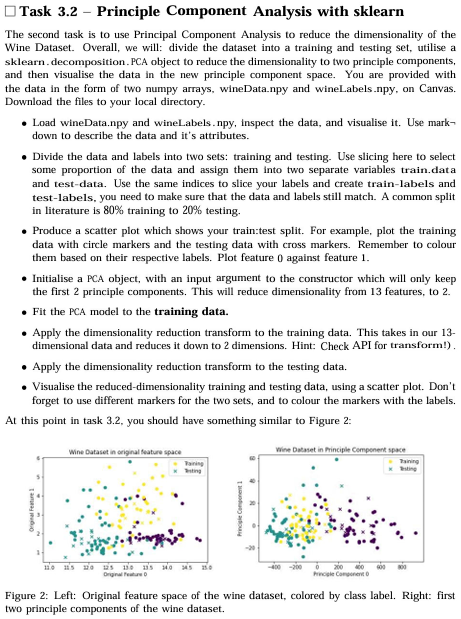

Visualize the data

In [ ]:
print(f"Wine Data:- \nMatrix dim: {wine_data.shape}\nData: \n{wine_data}")
print("-"*100)
#print(wine_data[0][1])
#lst_wine_data = list(wine_data)
#print(lst_wine_data[0,1])
print("-"*100)
print(f"Wine Labels:- \nTypes: {np.unique(wine_labels)} \nMatrix dim: {wine_labels.shape} \nLabels:\n{wine_labels}")



Wine Data:- 
Matrix dim: (178, 13)
Data: 
[[1.362e+01 4.950e+00 2.350e+00 ... 9.100e-01 2.050e+00 5.500e+02]
 [1.182e+01 1.720e+00 1.880e+00 ... 9.400e-01 2.440e+00 4.150e+02]
 [1.388e+01 5.040e+00 2.230e+00 ... 5.800e-01 1.330e+00 4.150e+02]
 ...
 [1.225e+01 1.730e+00 2.120e+00 ... 1.000e+00 3.170e+00 5.100e+02]
 [1.330e+01 1.720e+00 2.140e+00 ... 1.020e+00 2.770e+00 1.285e+03]
 [1.251e+01 1.240e+00 2.250e+00 ... 7.500e-01 1.510e+00 6.500e+02]]
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Wine Labels:- 
Types: [0 1 2] 
Matrix dim: (178,) 
Labels:
[2 1 2 2 2 2 1 2 0 2 0 0 0 1 2 2 0 0 2 0 2 2 0 1 1 0 1 2 0 0 2 1 0 0 2 0 0
 2 1 0 0 1 1 0 1 0 0 2 2 1 1 1 2 0 1 2 0 2 2 0 0 1 1 0 1 0 1 1 0 2 1 1 1 1
 0 1 2 0 2 1 1 1 1 2 0 0 1 2 0 1 0 0 0 0 1 1 0 2 2 0 1 0 2 2 0 2 0 1 1 0 0
 1 1 1 0 2 1 0 1 1 1 1 1 1 2 1 1 2 2 1 0 1 1 2 1 1 0 1 2 2 1 0 1

Wine Data -


*   178 Samples
*   13 Dimensions

Wine Lables


*   1 label for each sample
* There are 3 types or classifications based on the label details





Split into train and test data

In [5]:
train_wine_data, test_wine_data, train_wine_labels, test_wine_labels = train_test_split(
                                                          wine_data,
                                                          wine_labels,
                                                          test_size = 0.2,
                                                          random_state = 20
                                                         )


print("Train Dataset - Wine data")
print(f"\nMatrix dim:: {train_wine_data.shape}\nData: \n{train_wine_data}")
print("-"*100)
print("Train Dataset - Label data")
print(f"\nMatrix dim:: {train_wine_labels.shape}\nLabels: \n{train_wine_labels}")


print("-"*100)
print("-"*100)

print("Train Dataset - Wine data")
print(f"\nMatrix dim:: {test_wine_data.shape}\nData: \n{test_wine_data}")
print("-"*100)
print("Train Dataset - Label data")
print(f"\nMatrix dim:: {test_wine_labels.shape}\nLabels: \n{test_wine_labels}")



Train Dataset - Wine data

Matrix dim:: (142, 13)
Data: 
[[1.182e+01 1.720e+00 1.880e+00 ... 9.400e-01 2.440e+00 4.150e+02]
 [1.242e+01 1.610e+00 2.190e+00 ... 1.060e+00 2.960e+00 3.450e+02]
 [1.242e+01 2.550e+00 2.270e+00 ... 8.600e-01 3.300e+00 3.150e+02]
 ...
 [1.243e+01 1.530e+00 2.290e+00 ... 6.900e-01 2.840e+00 3.520e+02]
 [1.317e+01 2.590e+00 2.370e+00 ... 6.000e-01 1.620e+00 8.400e+02]
 [1.386e+01 1.350e+00 2.270e+00 ... 1.010e+00 3.550e+00 1.045e+03]]
----------------------------------------------------------------------------------------------------
Train Dataset - Label data

Matrix dim:: (142,)
Labels: 
[1 1 1 1 2 2 0 0 2 0 0 1 0 0 0 0 2 1 1 1 0 1 2 0 0 2 2 0 1 1 1 0 0 1 1 1 2
 2 2 2 2 0 1 0 1 2 0 0 1 2 2 0 2 1 1 1 1 2 2 1 2 1 2 1 1 0 1 1 0 2 1 0 2 0
 0 1 1 0 0 0 0 1 0 1 2 2 1 1 1 2 0 1 2 2 0 1 2 1 1 0 0 1 2 2 1 2 1 0 1 0 0
 2 2 1 0 0 0 0 2 1 1 0 0 2 1 2 0 2 2 0 1 0 1 0 1 0 1 0 1 1 2 0]
----------------------------------------------------------------------------------------

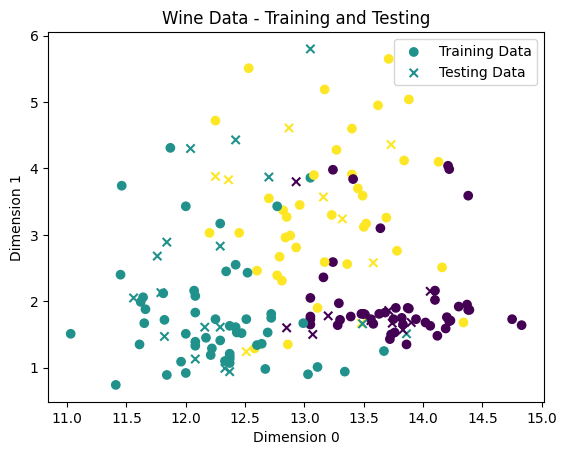

In [6]:
plt.ion()

figure = plt.subplot()


figure.scatter(
               train_wine_data[:,0],
               train_wine_data[:,1],
               c = train_wine_labels,
               label = "Training Data"
              )
figure.scatter(
                test_wine_data[:,0],
                test_wine_data[:,1],
                c=test_wine_labels,
                marker = "x",
                label = "Testing Data"
              )

figure.set_xlabel("Dimension 0")
figure.set_ylabel("Dimension 1")
figure.set_title("Wine Data - Training and Testing")

figure.legend()

plt.show()

In [ ]:
pca = PCA(n_components = 2)
pca.fit(train_wine_data)

train_wine_data_pca = pca.transform(train_wine_data)

print(train_wine_data_pca.shape)
print(train_wine_data_pca)


(142, 2)
[[-3.45852219e+02 -8.35495661e+00]
 [-4.15486355e+02  1.48789143e+01]
 [-4.45778408e+02 -2.61356803e+00]
 [-3.40823491e+02 -7.42144199e+00]
 [-2.30567262e+02  7.82339604e+00]
 [-1.30277500e+02  2.40616797e+01]
 [ 7.49318879e+02 -7.41426689e+00]
 [ 4.74800372e+02  2.41386762e+01]
 [-2.60254092e+02  2.74957832e+01]
 [ 4.24297819e+02 -6.03098999e+00]
 [ 6.97019275e+01  2.29833885e+01]
 [-1.00840299e+02 -1.03988087e+01]
 [ 4.29487358e+02  3.73715307e+00]
 [ 8.42553641e+01 -5.41554543e+00]
 [ 5.49470153e+02  2.87598365e+00]
 [ 4.99416257e+02 -2.65183598e-01]
 [-4.08560315e+01 -1.02786862e+01]
 [-3.68826413e+02 -8.05372323e+00]
 [-2.50960116e+02 -1.59134492e+01]
 [-1.35096286e+02  3.62238569e+01]
 [-2.53656720e+01  1.84345787e+01]
 [-4.48731165e+02 -6.71518763e-01]
 [-1.30461687e+02  1.44004259e+01]
 [ 6.89458015e+02  4.90309594e-01]
 [ 8.46103085e+01  1.44359634e+01]
 [-2.10770962e+02 -4.50372488e+00]
 [-1.45810218e+02 -7.42203671e+00]
 [ 1.97868272e+01  2.55280919e+01]
 [-2.509920

In [ ]:
test_wine_data_pca = pca.transform(test_wine_data)
print(test_wine_data_pca.shape)
print(test_wine_data_pca)


(36, 2)
[[-131.03501161  -19.73774929]
 [-110.89069709  -13.22671709]
 [ 259.2785108    -6.45270171]
 [-295.33158089   24.14755911]
 [ 534.61512241   12.08951899]
 [-297.62004091    5.97414362]
 [-350.86332485   -8.06196736]
 [-380.85097787   -7.68604824]
 [-470.79141712   -4.34405661]
 [-110.78312328   -6.03609895]
 [-240.8308737    -7.92107203]
 [-240.801935     -8.39119733]
 [ -10.04943919   35.94084678]
 [-294.79346609   -2.87569218]
 [ 109.35726985    1.18329751]
 [ 254.22083249   -9.28727737]
 [-135.88263288  -11.62952669]
 [ 289.32686456   -5.08702753]
 [-153.5979671     5.51406034]
 [-265.86959625   -9.63707908]
 [-395.60587377    8.70406233]
 [-265.8102495    -5.5556779 ]
 [-140.821608     -8.45068239]
 [  94.5267728    10.4546096 ]
 [-260.42824593   16.18377471]
 [ 299.60797722   12.93734373]
 [ 369.53590933    8.92413741]
 [ 274.32460298   -3.66663741]
 [-288.85594423   -8.11137878]
 [  69.34630283    0.89391594]
 [ 224.34132755   -2.82083319]
 [   9.37179599    1.79483451]


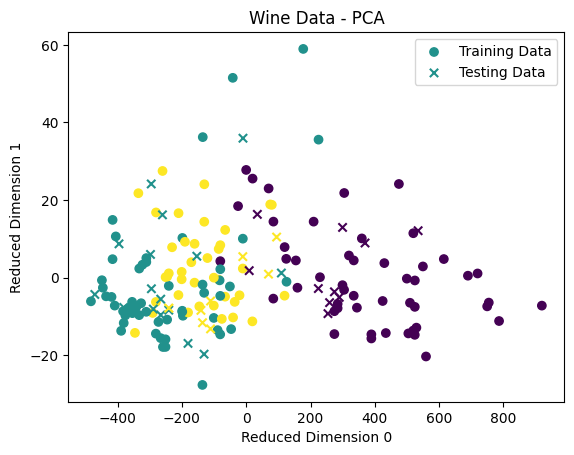

In [ ]:
plt.ion()

figure = plt.subplot()

figure.scatter(
               train_wine_data_pca[:,0],
               train_wine_data_pca[:,1],
               c = train_wine_labels,
               label = "Training Data"
              )

figure.scatter(
                test_wine_data_pca[:,0],
                test_wine_data_pca[:,1],
                c = test_wine_labels,
                marker = "x",
                label = "Testing Data"
                )

figure.set_xlabel("Reduced Dimension 0")
figure.set_ylabel("Reduced Dimension 1")
figure.set_title("Wine Data - PCA")

figure.legend()

plt.show()

# Task 3 - LDA

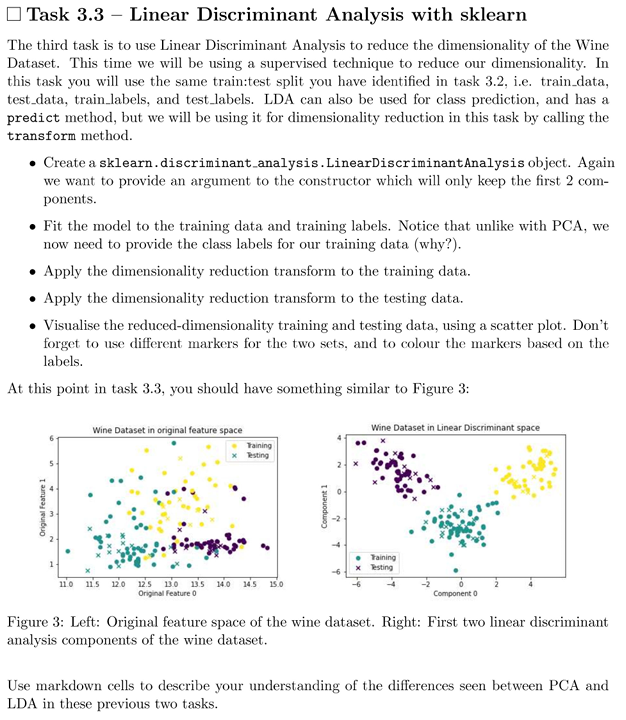

In [7]:
lda= LDA(n_components = 2)
lda.fit(train_wine_data, train_wine_labels)

train_wine_data_lda = lda.transform(train_wine_data)
test_wine_data_lda = lda.transform(test_wine_data)

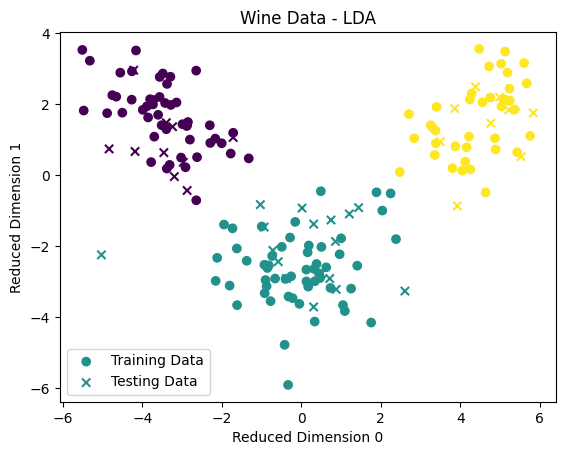

In [8]:
plt.ion()

figure = plt.subplot()

figure.scatter(
               train_wine_data_lda[:,0],
               train_wine_data_lda[:,1],
               c=train_wine_labels,
               label="Training Data"
              )

figure.scatter(
                test_wine_data_lda[:,0],
                test_wine_data_lda[:,1],
                c=test_wine_labels,
                marker="x",
                label="Testing Data"
                )

figure.set_xlabel("Reduced Dimension 0")
figure.set_ylabel("Reduced Dimension 1")
figure.set_title("Wine Data - LDA")

figure.legend()

plt.show()

#Task 4 - PCA by hand

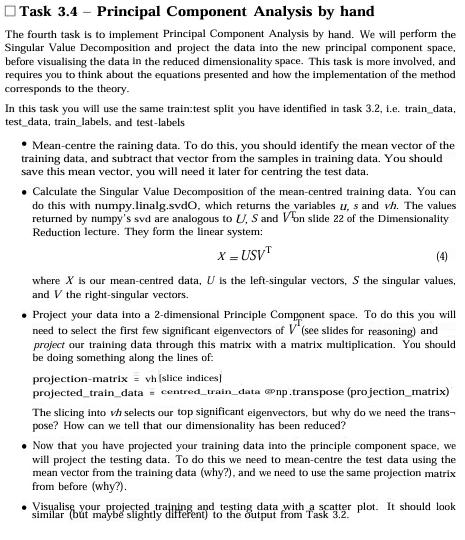

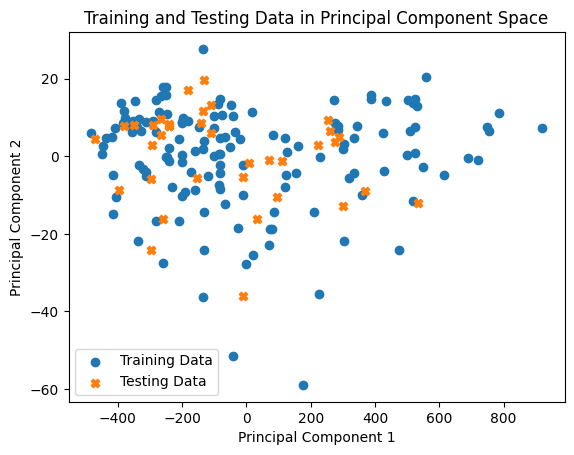

In [19]:
#Split data into
train_wine_data, test_wine_data, train_wine_labels, test_wine_labels = train_test_split(
                                                          wine_data,
                                                          wine_labels,
                                                          test_size = 0.2,
                                                          random_state = 20
                                                         )
#Mean value for each dimension - a vector array
mean_vector = np.mean(train_wine_data, axis = 0)

#Mean center array vector #standard deviation vector array
mean_center = train_wine_data - mean_vector
mean_center_test = test_wine_data - mean_vector

#SVD calculation for standard deviation vector
U, S, Vh = np.linalg.svd(mean_center, full_matrices= False)

#projection matrix
projection_matrix = Vh[:2,:]
projection_train_data = np.dot(mean_center, np.transpose(projection_matrix))
projection_test_data = np.dot(mean_center_test, np.transpose(projection_matrix))

plt.ion()
plt.scatter(projection_train_data[:, 0], projection_train_data[:, 1], label = 'Training Data')
plt.scatter(projection_test_data[:, 0], projection_test_data[:, 1], marker = "X", label = 'Testing Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.title('Training and Testing Data in Principal Component Space')
plt.show()









## Find no of features for 95% variance

In [55]:
pca = PCA()
pca.fit(train_wine_data)

# Calculate the cumulative explained variance
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

# Find the number of components needed to reach 95% variance
n_components = np.argmax(cumulative_variance_ratio >= 0.95) + 1

print("Number of components needed to reach 90% variance:", n_components)

Number of components needed to reach 90% variance: 1


##Rough work

In [42]:
print( Vh[0][1])
print( Vh[1][0])

-0.0005135799478322989
-0.0032746985484626437


In [ ]:
projection_matrix.shape

(1, 13)

In [ ]:
np.transpose(projection_matrix).shape

(13, 1)

In [ ]:
U, S, Vh = np.linalg.svd(mean_center,  full_matrices= False)

print(U.shape, S.shape, Vh.shape)

(142, 13) (13,) (13, 13)


#Task 5 - Apply your skill

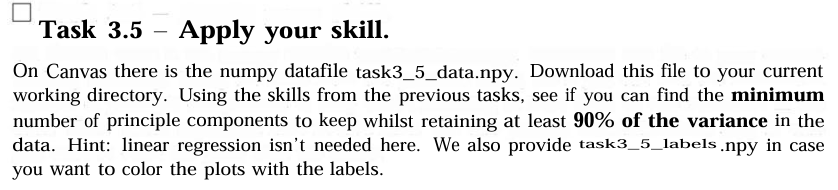

In [13]:
task5_data.shape

(60000, 784)

In [14]:
task5_labels.shape

(60000,)

In [11]:
#Split data into
train_task5_data, test_task5_data, train_task5_labels, test_task5_labels = train_test_split(
                                                          task5_data,
                                                          task5_labels,
                                                          test_size = 0.2,
                                                          random_state = 20
                                                         )

In [25]:
train_task5_data.shape

(48000, 784)

In [26]:
test_task5_data.shape

(12000, 784)

In [12]:
pca = PCA()
pca.fit(train_task5_data)

# Calculate the cumulative explained variance
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

# Find the number of components needed to reach 95% variance
n_components = np.argmax(cumulative_variance_ratio >= 0.90) + 1

print("Number of components needed to reach 90% variance:", n_components)

Number of components needed to reach 90% variance: 87


In [15]:
pca.explained_variance_ratio_

array([9.68323277e-02, 7.12656505e-02, 6.16432615e-02, 5.39776307e-02,
       4.85445947e-02, 4.30433441e-02, 3.27765486e-02, 2.89339860e-02,
       2.75798125e-02, 2.35055317e-02, 2.10316485e-02, 2.02309776e-02,
       1.71910477e-02, 1.69040010e-02, 1.58774763e-02, 1.48662940e-02,
       1.31683071e-02, 1.27399779e-02, 1.19115584e-02, 1.15128600e-02,
       1.06975654e-02, 1.00374415e-02, 9.55234628e-03, 9.14861716e-03,
       8.82297845e-03, 8.40235043e-03, 8.12395114e-03, 7.83590680e-03,
       7.45281380e-03, 6.92612720e-03, 6.59256670e-03, 6.46744245e-03,
       5.99106383e-03, 5.86993243e-03, 5.71691711e-03, 5.42402930e-03,
       5.06626615e-03, 4.87374829e-03, 4.82205243e-03, 4.74396984e-03,
       4.57595823e-03, 4.43471843e-03, 4.18829396e-03, 4.00251873e-03,
       3.84625329e-03, 3.76260176e-03, 3.62416678e-03, 3.51111495e-03,
       3.40690519e-03, 3.21402142e-03, 3.18935121e-03, 3.13268188e-03,
       2.96840603e-03, 2.89218102e-03, 2.84689531e-03, 2.70875778e-03,
      

In [16]:
cumulative_variance_ratio

array([0.09683233, 0.16809798, 0.22974124, 0.28371887, 0.33226347,
       0.37530681, 0.40808336, 0.43701734, 0.46459716, 0.48810269,
       0.50913434, 0.52936531, 0.54655636, 0.56346036, 0.57933784,
       0.59420413, 0.60737244, 0.62011242, 0.63202398, 0.64353684,
       0.6542344 , 0.66427184, 0.67382419, 0.68297281, 0.69179579,
       0.70019814, 0.70832209, 0.71615799, 0.72361081, 0.73053693,
       0.7371295 , 0.74359694, 0.74958801, 0.75545794, 0.76117486,
       0.76659889, 0.77166515, 0.7765389 , 0.78136095, 0.78610492,
       0.79068088, 0.7951156 , 0.79930389, 0.80330641, 0.80715267,
       0.81091527, 0.81453943, 0.81805055, 0.82145745, 0.82467148,
       0.82786083, 0.83099351, 0.83396191, 0.8368541 , 0.83970099,
       0.84240975, 0.84509999, 0.8476921 , 0.85024364, 0.8527024 ,
       0.8551079 , 0.85749951, 0.85977983, 0.86199865, 0.86413252,
       0.86620853, 0.8682452 , 0.87021108, 0.87214934, 0.87402624,
       0.87589517, 0.87770925, 0.87948655, 0.88123307, 0.88289

##PCA

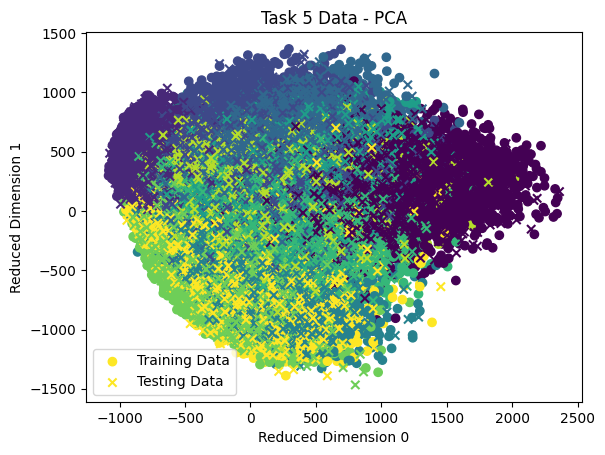

In [31]:
pca = PCA(n_components = 87)
pca.fit(train_task5_data)

train_task5_data_pca = pca.transform(train_task5_data)
test_task5_data_pca = pca.transform(test_task5_data)

plt.ion()

figure = plt.subplot()

figure.scatter(
               train_task5_data_pca[:,0],
               train_task5_data_pca[:,1],
               c = train_task5_labels,
               label = "Training Data"
              )

figure.scatter(
                test_task5_data_pca[:,0],
                test_task5_data_pca[:,1],
                c  = test_task5_labels,
                marker="x",
                label="Testing Data"
                )

figure.set_xlabel("Reduced Dimension 0")
figure.set_ylabel("Reduced Dimension 1")
figure.set_title("Task 5 Data - PCA")

figure.legend()

plt.show()

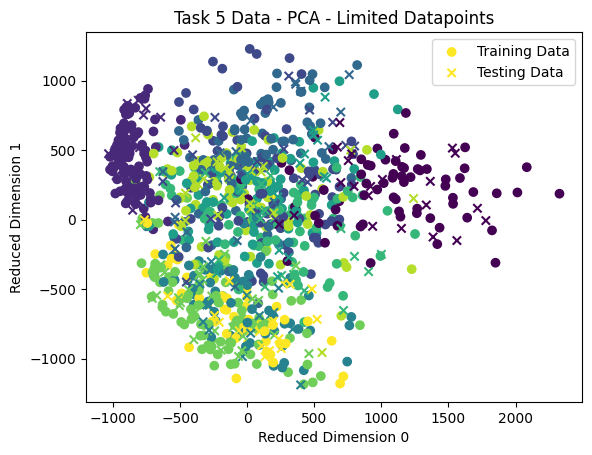

In [32]:
plt.ion()

figure = plt.subplot()

figure.scatter(
               train_task5_data_pca[:800,0],
               train_task5_data_pca[:800,1],
               c = train_task5_labels[:800],
               label = "Training Data"
              )

figure.scatter(
                test_task5_data_pca[:200,0],
                test_task5_data_pca[:200,1],
                c  = test_task5_labels[:200],
                marker="x",
                label="Testing Data"
                )

figure.set_xlabel("Reduced Dimension 0")
figure.set_ylabel("Reduced Dimension 1")
figure.set_title("Task 5 Data - PCA - Limited Datapoints")

figure.legend()

plt.show()

##LDA

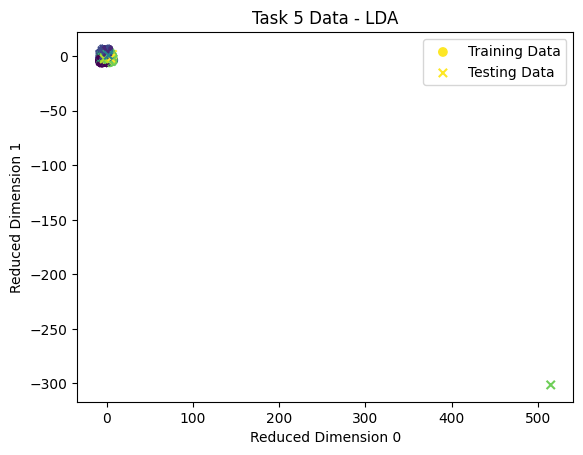

In [42]:
lda= LDA(n_components = 9)
lda.fit(train_task5_data, train_task5_labels)

train_task5_data_lda = lda.transform(train_task5_data)
test_task5_data_lda = lda.transform(test_task5_data)


plt.ion()

figure = plt.subplot()

figure.scatter(
               train_task5_data_lda[:,0],
               train_task5_data_lda[:,1],
               c = train_task5_labels,
               label = "Training Data"
              )

figure.scatter(
                test_task5_data_lda[:,0],
                test_task5_data_lda[:,1],
                c  = test_task5_labels,
                marker="x",
                label="Testing Data"
                )

figure.set_xlabel("Reduced Dimension 0")
figure.set_ylabel("Reduced Dimension 1")
figure.set_title("Task 5 Data - LDA")

figure.legend()

plt.show()

In [41]:
np.unique(train_task5_labels)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)